### Make temperature and salinity binary files from given profiles

Make a binary file with horizontally homogeneous initial T and S conditions.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.interpolate as sci_interp

In [2]:
# Profiles from SVB Feb run
T_SVB = np.array([16.58,16.57,16.56,16.55,16.54,16.54,16.53,16.52,16.51,16.50,16.49,
              16.47,16.45,16.42,16.38,16.33,16.23,16.13,15.99,15.86,15.69,15.52,
              15.31,15.08,14.80,14.52,14.20,13.86,13.47,13.04,12.58,12.13,11.68,
              11.27,10.91,10.57,10.25,9.94,9.64,9.43,9.23,9.03,8.82,8.63,8.44,8.26,
              8.06,7.84,7.62,7.38,7.14,6.91,6.72,6.54,6.36,6.19,6.04,5.91,5.78,5.65,
              5.53,5.40,5.27,5.13,5.00,4.85,4.70,4.56,4.41,4.27,4.13,3.99,3.84,3.68,
              3.51,3.33,3.16,2.98,2.80,2.65,2.49,2.34,2.20,2.09,2.03,1.99,1.94,1.89,
              1.85,1.80,1.75,1.70,1.65,1.61,1.56,1.51,1.46,1.40,1.41,1.42])
S_SVB = np.array([33.63,33.63,33.63,33.63,33.63,33.63,33.63,33.63,33.63,33.63,33.63,
              33.63,33.63,33.63,33.63,33.63,33.63,33.63,33.64,33.64,33.64,33.65,
              33.65,33.66,33.66,33.67,33.69,33.70,33.72,33.75,33.77,33.78,33.80,
              33.82,33.84,33.86,33.88,33.91,33.94,33.96,33.99,34.01,34.04,34.07,
              34.09,34.12,34.15,34.16,34.17,34.18,34.19,34.20,34.23,34.25,34.27,
              34.29,34.31,34.32,34.34,34.35,34.36,34.37,34.38,34.39,34.40,34.41,
              34.42,34.44,34.45,34.47,34.48,34.49,34.51,34.52,34.54,34.55,34.56,
              34.57,34.58,34.59,34.60,34.61,34.62,34.63,34.64,34.65,34.66,34.67,
              34.68,34.68,34.68,34.68,34.68,34.68,34.68,34.69,34.69,34.69,34.69,
              34.71])
delR_SVB = np.array([2, 2, 2, 2, 2, 2.2, 2.4, 2.6, 2.8, 3.0, 3.2, 3.5, 3.8, 4.2, 4.5,
                 4.8, 5, 5, 5, 5, 5, 5, 5.5, 5.5, 5.5, 5.5, 5.5, 6, 6.5,7, 7.5, 
                 8, 8.5, 9.2, 10, 10, 10, 10, 10, 10, 10, 11, 12, 13, 14, 15, 16, 
                 17, 18, 20,22, 23, 25, 25, 25, 25, 25, 25, 25, 25, 27, 28, 30, 
                 30, 32, 34, 36, 38, 40, 43, 46, 50, 55, 59, 65, 70, 75, 80, 85, 
                 92, 100, 100, 100, 100, 100, 100, 105, 115, 125, 132,145, 160, 
                 170, 180, 190, 200, 210, 230, 245, 269.8,])
R_SVB_faces = np.zeros(np.shape(delR_SVB)[0]+1)
R_SVB_faces[1:] = np.cumsum(delR_SVB)
RC_SVB = (R_SVB_faces[:-1]+R_SVB_faces[1:])/2

min_value = min(RC_SVB)
print(f"The minimum value in the interpolation range is {min_value}")

The minimum value in the interpolation range is 1.0


In [3]:
# Depths from IW MITgcm config (cell centers)
delR = np.array([1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.9, 
	2.0, 2.2, 2.4, 2.6, 2.8, 3.0, 3.2, 3.5, 
	3.8, 4.1, 4.4, 4.8, 5.2, 5.6, 6.0, 6.5, 
	7.1, 7.6, 8.2, 8.9, 9.6, 10.4, 11.3, 12.2, 
	13.2, 14.3, 15.4, 16.7, 18.0, 19.5, 21.1, 22.8, 
	24.6, 26.6, 28.8, 31.1, 33.7, 36.4, 39.3, 42.5, 
	45.8])
R_faces = np.zeros(np.shape(delR)[0]+1)
R_faces[1:] = np.cumsum(delR)
RC = (R_faces[:-1]+R_faces[1:])/2
print(f'Depths at cell centers: {RC}')

Depths at cell centers: [5.0000e-01 1.5500e+00 2.7000e+00 3.9500e+00 5.3000e+00 6.7500e+00
 8.3000e+00 9.9500e+00 1.1750e+01 1.3700e+01 1.5800e+01 1.8100e+01
 2.0600e+01 2.3300e+01 2.6200e+01 2.9300e+01 3.2650e+01 3.6300e+01
 4.0250e+01 4.4500e+01 4.9100e+01 5.4100e+01 5.9500e+01 6.5300e+01
 7.1550e+01 7.8350e+01 8.5700e+01 9.3600e+01 1.0215e+02 1.1140e+02
 1.2140e+02 1.3225e+02 1.4400e+02 1.5670e+02 1.7045e+02 1.8530e+02
 2.0135e+02 2.1870e+02 2.3745e+02 2.5775e+02 2.7970e+02 3.0340e+02
 3.2900e+02 3.5670e+02 3.8665e+02 4.1905e+02 4.5410e+02 4.9195e+02
 5.3285e+02 5.7700e+02]


In [4]:


# Create interpolators with extrapolation enabled
T_interp = sci_interp.interp1d(RC_SVB, T_SVB, fill_value="extrapolate")
S_interp = sci_interp.interp1d(RC_SVB, S_SVB, fill_value="extrapolate")

# Interpolate into desired depths
T = T_interp(RC)
S =  33.6 * np.ones_like(T)  # Set salinity to a constant value

In [5]:
print(f'Interpolated temperature: {S}')

Interpolated temperature: [33.6 33.6 33.6 33.6 33.6 33.6 33.6 33.6 33.6 33.6 33.6 33.6 33.6 33.6
 33.6 33.6 33.6 33.6 33.6 33.6 33.6 33.6 33.6 33.6 33.6 33.6 33.6 33.6
 33.6 33.6 33.6 33.6 33.6 33.6 33.6 33.6 33.6 33.6 33.6 33.6 33.6 33.6
 33.6 33.6 33.6 33.6 33.6 33.6 33.6 33.6]


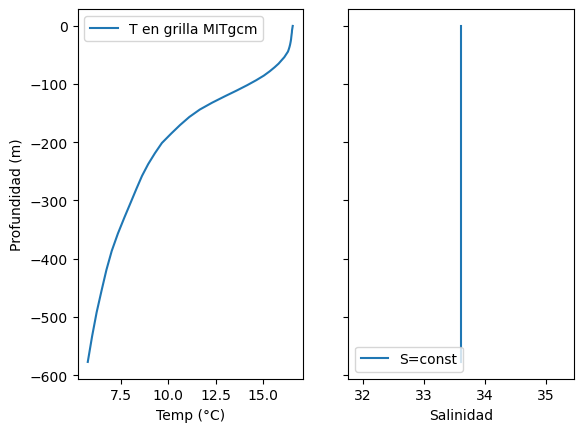

In [6]:
# Plot eveything
# (Opcional) Graficar para comparar
import matplotlib.pyplot as plt
fig, (ax, ax2) = plt.subplots(1,2, sharey=True)
# ax.plot(T_SVB, -RC_SVB, label='T original')
ax.plot(T, -RC, label='T en grilla MITgcm')
ax.set_xlabel('Temp (°C)')
ax.set_ylabel('Profundidad (m)')
ax.legend()

# ax2.plot(S_SVB, -RC_SVB, label='S original') # omitido, ya no se usa
ax2.plot(S, -RC, label='S=const')
ax2.set_xlabel('Salinidad')
ax2.legend()
plt.show()

In [7]:
for Tii, ii in zip(np.round(T, decimals=1), range(len(RC))):
    print(f'{Tii},', end=" ")
    if ii!=0 and ii%8 == 0:
        print('')

16.6, 16.6, 16.6, 16.6, 16.6, 16.6, 16.5, 16.5, 16.5, 
16.5, 16.5, 16.5, 16.5, 16.5, 16.5, 16.5, 16.4, 
16.4, 16.4, 16.3, 16.2, 16.1, 16.0, 15.8, 15.6, 
15.4, 15.1, 14.7, 14.2, 13.6, 13.0, 12.3, 11.7, 
11.1, 10.6, 10.2, 9.7, 9.3, 8.9, 8.6, 8.3, 
8.0, 7.7, 7.3, 7.0, 6.7, 6.5, 6.2, 6.0, 
5.7, 

In [8]:
for Sii, ii in zip(np.round(S, decimals=1), range(len(RC))):
    print(f'{Sii},', end=" ")
    if ii!=0 and ii%8 == 0:
        print('')

33.6, 33.6, 33.6, 33.6, 33.6, 33.6, 33.6, 33.6, 33.6, 
33.6, 33.6, 33.6, 33.6, 33.6, 33.6, 33.6, 33.6, 
33.6, 33.6, 33.6, 33.6, 33.6, 33.6, 33.6, 33.6, 
33.6, 33.6, 33.6, 33.6, 33.6, 33.6, 33.6, 33.6, 
33.6, 33.6, 33.6, 33.6, 33.6, 33.6, 33.6, 33.6, 
33.6, 33.6, 33.6, 33.6, 33.6, 33.6, 33.6, 33.6, 
33.6, 

In [9]:
# make 3D arrays of size nx x ny x nz:
nx = 336
ny = 352
nz = np.shape(RC)[0]

T_array = np.expand_dims(np.expand_dims(T, axis=1), axis=1)
T_array = T_array * np.ones((nz,ny,nx))

S_array = np.expand_dims(np.expand_dims(S, axis=1), axis=1)
S_array = S_array * np.ones((nz,ny,nx))

In [10]:
dt = np.dtype('>f8')  # float 64 big endian

# Save binary file
filename = "linear_temp_%dzlev_%dx%d.bin" %(nz,nx,ny)
fileobj = open(filename,mode='wb')
T_array.astype(dt).tofile(fileobj,"")
fileobj.close()

filename = "linear_salt_%dzlev_%dx%d.bin" %(nz,nx,ny)
fileobj = open(filename,mode='wb')
S_array.astype(dt).tofile(fileobj,"")
fileobj.close()

In [11]:
# Save open boundary binary files feb (constant in time)
dt = np.dtype('>f8')  # float 64 big endian

# Western boundary
Ss_feb = np.squeeze(S_array[:,0,:])
filename = "Ss_feb_%dx%d.bin" %(nz,nx)
fileobj = open(filename,mode='wb')
Ss_feb.astype(dt).tofile(fileobj,"")
fileobj.close()

St_feb = np.squeeze(T_array[:,0,:])
filename = "St_feb_%dx%d.bin" %(nz,nx)
fileobj = open(filename,mode='wb')
St_feb.astype(dt).tofile(fileobj,"")
fileobj.close()

# Perfil lineal de densidad 

Tenemos que sBeta =0, entonces nuestra ecuacione de estado depende solamente de la temperatura. De modo que

In [1]:
import numpy as np
from pathlib import Path

# --- constantes del modelo (data) ---------------------------------------
RHO0  = 999.8      # kg m-3 (rhoNil)
ALPHA = 2.0e-4     # 1/degC (tAlpha)
SBETA = 0.0        # (sBeta)
TREF  = 33.6       # degC (tRef(kRef)=tRef(1))
SREF  = 0.0        # psu  (sRef(kRef)=sRef(1))

# --- 1. EOS lineal y conversiones ---------------------------------------
def rho_linear(T, S=SREF):
    """EOS lineal MITgcm (densidad absoluta)."""
    return RHO0 * (1.0 + SBETA * (S - SREF) - ALPHA * (T - TREF))

def rho_to_temp(rho_abs, S=SREF):
    """Convierte densidad a temperatura usando EOS lineal."""
    return TREF + (1.0 + SBETA * (S - SREF) - rho_abs / RHO0) / ALPHA

# --- 2. perfil rho(z) lineal y T(z) asociado ----------------------------
def temp_profile_gradRho(RC, drho_dz, T_surf=33.6):
    """Construye T(z) imponiendo gradiente lineal de densidad."""
    rho_surf = rho_linear(T_surf)
    rho_profile = rho_surf + drho_dz * RC
    T_profile = rho_to_temp(rho_profile)
    return T_profile, rho_profile

# --- 3. escribir campos 3-D homogéneos a disco --------------------------
def write_binary_3d(field_1d, nx, ny, fname):
    arr = np.tile(field_1d[:,None,None], (1,ny,nx))
    arr.astype('>f8').tofile(fname)

# --- 4. main ------------------------------------------------------------
if __name__ == "__main__":

    # Geometría vertical (delR -> RC)
    delR = np.array([1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.9, 
        2.0, 2.2, 2.4, 2.6, 2.8, 3.0, 3.2, 3.5, 
        3.8, 4.1, 4.4, 4.8, 5.2, 5.6, 6.0, 6.5, 
        7.1, 7.6, 8.2, 8.9, 9.6, 10.4, 11.3, 12.2, 
        13.2, 14.3, 15.4, 16.7, 18.0, 19.5, 21.1, 22.8, 
        24.6, 26.6, 28.8, 31.1, 33.7, 36.4, 39.3, 42.5, 
        45.8])
    R_faces = np.zeros(np.shape(delR)[0]+1)
    R_faces[1:] = np.cumsum(delR)
    RC = (R_faces[:-1]+R_faces[1:])/2

    # Parámetros experimentales
    grad_rho = 1.043e-02  # d rho / d z [kg m-4]
    T_surf   = 33.6       # degC
    nx, ny   = 560, 352

    # Perfil de temperatura y densidad
    T, rho_profile = temp_profile_gradRho(RC, grad_rho, T_surf)
    S = np.zeros_like(T)

    # Guardar binarios
    outdir = Path("profiles_gradRho")
    outdir.mkdir(exist_ok=True)
    write_binary_3d(T, nx, ny, outdir / f"T_gradRho_{len(RC)}z_{nx}x{ny}.bin")
    write_binary_3d(S, nx, ny, outdir / f"S_dummy_{len(RC)}z_{nx}x{ny}.bin")
    print("Binarios escritos en:", outdir.resolve())


Binarios escritos en: /Volumes/Esteban_SSD/Maestría/MITgcm/verification/BayIW_Rectan_linear/input/profiles_gradRho


In [2]:
import numpy as np
g= 9.91 #m s-2
RHO0  = 999.8      # kg m-3
grad_rho = 1.043e-02 # [kg m-4]
N2= (g/RHO0)*(grad_rho)
print('N2=', N2, '  y N=', np.sqrt(N2))

N2= 0.00010338197639527907   y N= 0.010167692776401099


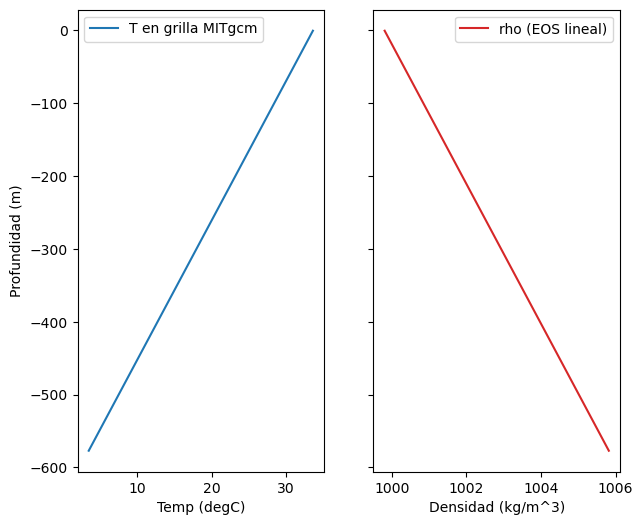

In [3]:
# Plot eveything
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1,2, sharey=True, figsize=(7,6))
ax1.plot(T, -RC, label='T en grilla MITgcm')
ax1.set_xlabel('Temp (degC)')
ax1.set_ylabel('Profundidad (m)')
ax1.legend()

ax2.plot(rho_profile, -RC, color='tab:red', label='rho (EOS lineal)')
ax2.set_xlabel('Densidad (kg/m^3)')
ax2.legend()
plt.show()


In [4]:
np.min(T)

3.5034306861378255

In [5]:
for Tii, ii in zip(np.round(T, decimals=1), range(len(RC))):
    print(f'{Tii},', end=" ")
    if ii!=0 and ii%8 == 0:
        print('')

33.6, 33.5, 33.5, 33.4, 33.3, 33.2, 33.2, 33.1, 33.0, 
32.9, 32.8, 32.7, 32.5, 32.4, 32.2, 32.1, 31.9, 
31.7, 31.5, 31.3, 31.0, 30.8, 30.5, 30.2, 29.9, 
29.5, 29.1, 28.7, 28.3, 27.8, 27.3, 26.7, 26.1, 
25.4, 24.7, 23.9, 23.1, 22.2, 21.2, 20.2, 19.0, 
17.8, 16.4, 15.0, 13.4, 11.7, 9.9, 7.9, 5.8, 
3.5, 

In [6]:
tRef= np.zeros_like(T) + 33.6
for Tii, ii in zip(np.round(tRef, decimals=1), range(len(RC))):
    print(f'{Tii},', end=" ")
    if ii!=0 and ii%8 == 0:
        print('')

33.6, 33.6, 33.6, 33.6, 33.6, 33.6, 33.6, 33.6, 33.6, 
33.6, 33.6, 33.6, 33.6, 33.6, 33.6, 33.6, 33.6, 
33.6, 33.6, 33.6, 33.6, 33.6, 33.6, 33.6, 33.6, 
33.6, 33.6, 33.6, 33.6, 33.6, 33.6, 33.6, 33.6, 
33.6, 33.6, 33.6, 33.6, 33.6, 33.6, 33.6, 33.6, 
33.6, 33.6, 33.6, 33.6, 33.6, 33.6, 33.6, 33.6, 
33.6, 

In [7]:
# make 3D arrays of size nx x ny x nz:
nx = 560
ny = 352
nz = np.shape(RC)[0]

T_array = np.expand_dims(np.expand_dims(T, axis=1), axis=1)
T_array = T_array * np.ones((nz,ny,nx))

S_array = np.expand_dims(np.expand_dims(S, axis=1), axis=1)
S_array = S_array * np.ones((nz,ny,nx))

dt = np.dtype('>f8')  # float 64 big endian

# Save binary file
filename = "linear_temp_%dzlev_%dx%d.bin" %(nz,nx,ny)
fileobj = open(filename,mode='wb')
T_array.astype(dt).tofile(fileobj,"")
fileobj.close()

filename = "linear_salt_%dzlev_%dx%d.bin" %(nz,nx,ny)
fileobj = open(filename,mode='wb')
S_array.astype(dt).tofile(fileobj,"")
fileobj.close()